C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\1410634092.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\1410634092.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_

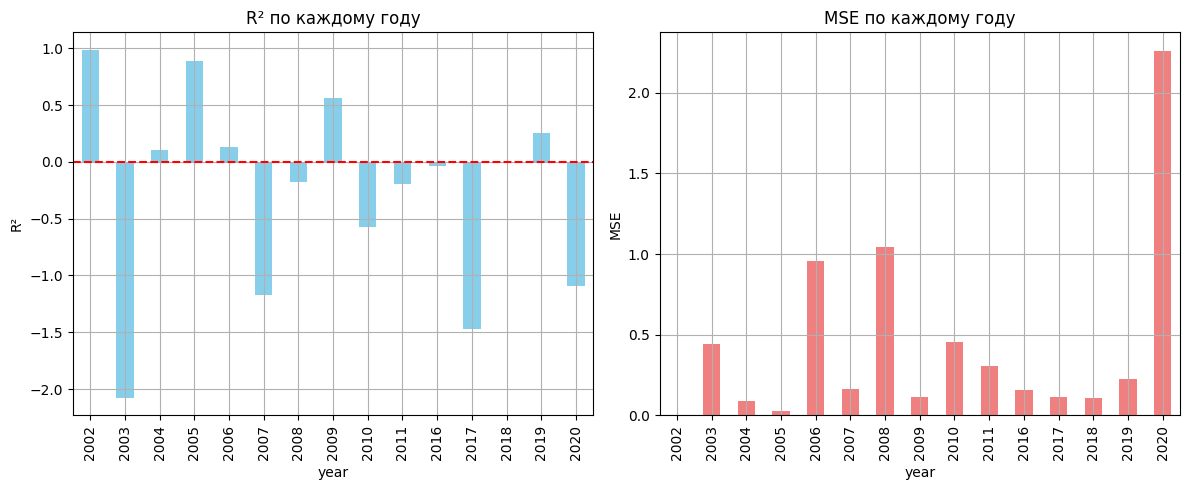

MSE: 0.3485
RMSE: 0.5903
R²: 0.1647


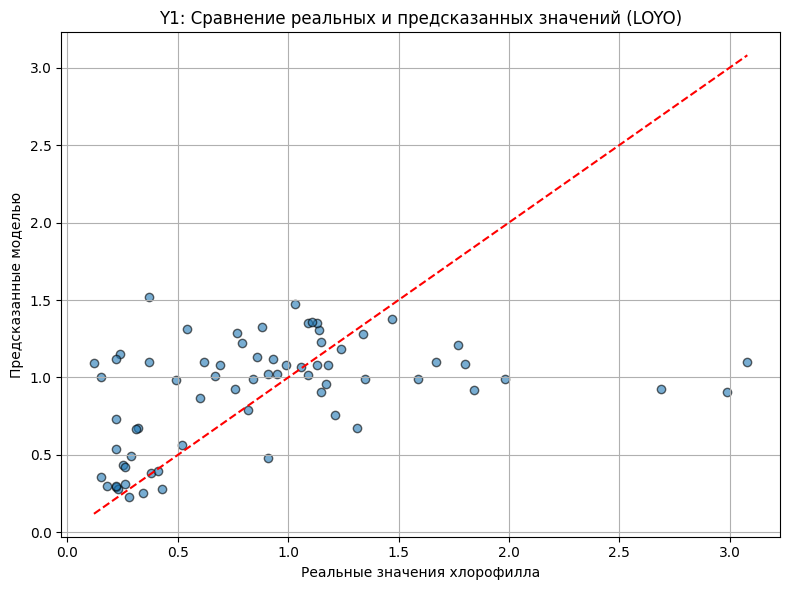

In [ ]:
#(глубина 0 м) — Hist - 70 строк обучения - без усреднения - не нормированные данные 

import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# --- Пути к данным ---
y1_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y1_(глубина_=_0).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

# --- Загрузка y1 ---
df_y = pd.read_csv(y1_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = df_y['chlorophyll'].astype(str).str.replace(r'[^0-9,\.]', '', regex=True).str.replace(',', '.')
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'], errors='coerce')

# --- Загрузка R1, R2, R3 ---
def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']]
    df = df.rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

# --- Загрузка S1, S2, S3 ---
def load_s(path, name):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df.columns = [f'{name}_{col}' for col in df.columns]
    return df

s1 = load_s(s1_path, 'S1')
s2 = load_s(s2_path, 'S2')
s3 = load_s(s3_path, 'S3')

# --- Объединение всех X ---
df_x = r1.merge(r2, on='date').merge(r3, on='date')
df_x = df_x.set_index('date')
df_x = df_x.join([s1, s2, s3])
df_x = df_x.reset_index()

# --- Слияние с y по дате ---
df = pd.merge(df_x, df_y, on='date', how='inner')
df = df.dropna(subset=['chlorophyll'])

# --- Подготовка признаков и групп ---
X = df.drop(columns=['date', 'chlorophyll'])
y = df['chlorophyll']
groups = df['date'].dt.year  # группировка по годам

# --- Leave-One-Year-Out кросс-валидация ---
model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
logo = LeaveOneGroupOut()
y_pred = cross_val_predict(model, X, y, cv=logo, groups=groups)


from sklearn.metrics import r2_score, mean_squared_error

# Группы по годам
years = df['date'].dt.year.unique()
years.sort()

# Массивы с предсказанием и истиной уже есть: y_pred, y
# Чтобы разбить по годам, нужно восстановить индексы:
df_result = df.copy()
df_result['y_true'] = y
df_result['y_pred'] = y_pred
df_result['year'] = df_result['date'].dt.year

# R² и MSE по каждому году
r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pred']))

# Построим графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
r2_by_year.plot(kind='bar', color='skyblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('R² по каждому году')
plt.ylabel('R²')
plt.grid(True)

plt.subplot(1, 2, 2)
mse_by_year.plot(kind='bar', color='lightcoral')
plt.title('MSE по каждому году')
plt.ylabel('MSE')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Метрики ---
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


# --- График предсказаний ---
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Реальные значения хлорофилла")
plt.ylabel("Предсказанные моделью")
plt.title("Y1: Сравнение реальных и предсказанных значений (LOYO)")
plt.grid(True)
plt.tight_layout()
plt.show()




MSE (без плохих лет): 0.3493
RMSE (без плохих лет): 0.5910
R² (без плохих лет): 0.1514


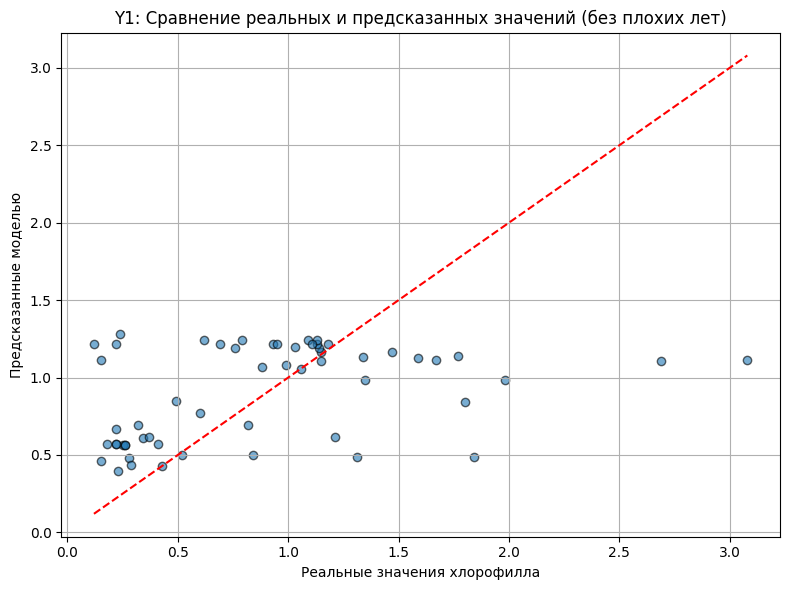

In [ ]:
#(глубина 0 м) — Hist - 70 строк обучения - без усреднения - не нормированные данные - без плохих лет 

import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Пути к данным — используй свои пути
y1_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y1_(глубина_=_0).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

# Загрузка y1
df_y = pd.read_csv(y1_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = df_y['chlorophyll'].astype(str).str.replace(r'[^0-9,\.]', '', regex=True).str.replace(',', '.')
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'], errors='coerce')

# Функции загрузки R и S данных
def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']]
    df = df.rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

def load_s(path, name):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df.columns = [f'{name}_{col}' for col in df.columns]
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

s1 = load_s(s1_path, 'S1')
s2 = load_s(s2_path, 'S2')
s3 = load_s(s3_path, 'S3')

# Объединение X
df_x = r1.merge(r2, on='date').merge(r3, on='date')
df_x = df_x.set_index('date')
df_x = df_x.join([s1, s2, s3])
df_x = df_x.reset_index()

# Объединение с y
df = pd.merge(df_x, df_y, on='date', how='inner')
df = df.dropna(subset=['chlorophyll'])

# Добавим колонку year
df['year'] = df['date'].dt.year

# Исключаем проблемные годы
bad_years = [2003, 2007, 2017, 2020]
df_clean = df[~df['year'].isin(bad_years)]

# Формируем признаки и целевую переменную
X = df_clean.drop(columns=['date', 'chlorophyll', 'year'])
y = df_clean['chlorophyll']
groups = df_clean['year']

# Модель и Leave-One-Year-Out CV
model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
logo = LeaveOneGroupOut()
y_pred = cross_val_predict(model, X, y, cv=logo, groups=groups)

# Метрики
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"MSE (без плохих лет): {mse:.4f}")
print(f"RMSE (без плохих лет): {rmse:.4f}")
print(f"R² (без плохих лет): {r2:.4f}")

# График
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Реальные значения хлорофилла")
plt.ylabel("Предсказанные моделью")
plt.title("Y1: Сравнение реальных и предсказанных значений (без плохих лет)")
plt.grid(True)
plt.tight_layout()
plt.show()


Количество недельных строк после объединения R и Y: 230


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

Форма X_R: (230, 3)
Форма X_RS: (230, 6462)


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_


R + Y
Общие метрики: MSE=0.2972, RMSE=0.5451, R²=0.1043


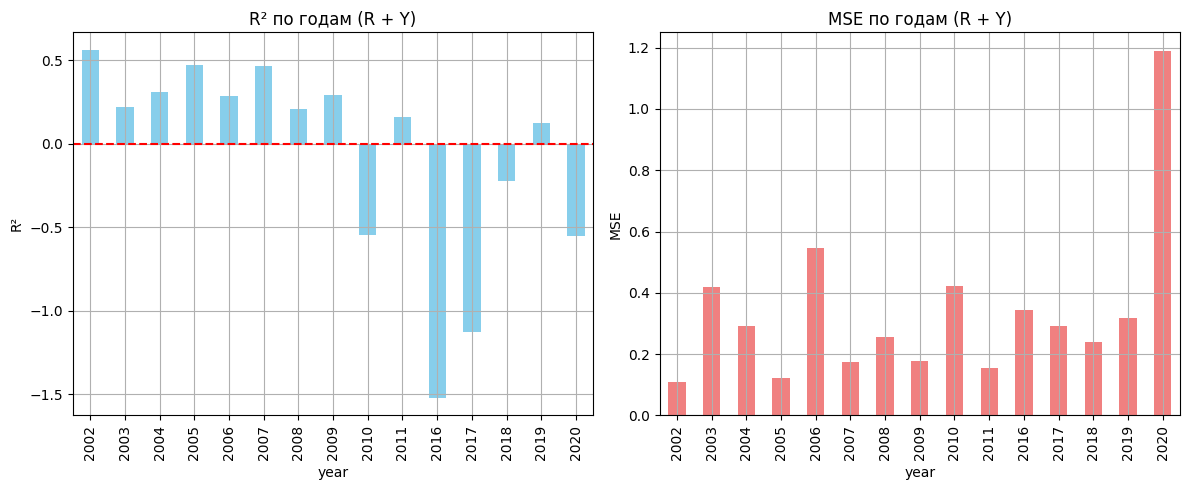

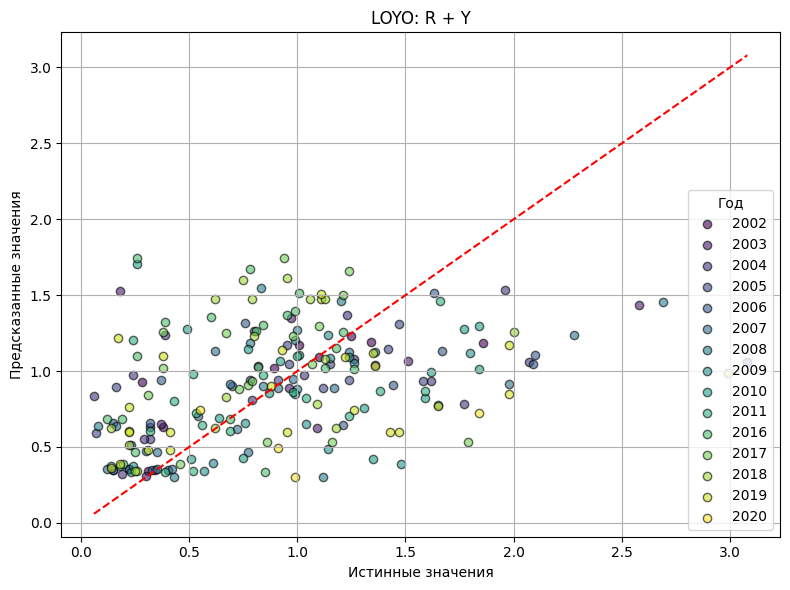

C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\2708040059.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_


R + Y + S
Общие метрики: MSE=0.2610, RMSE=0.5109, R²=0.2134


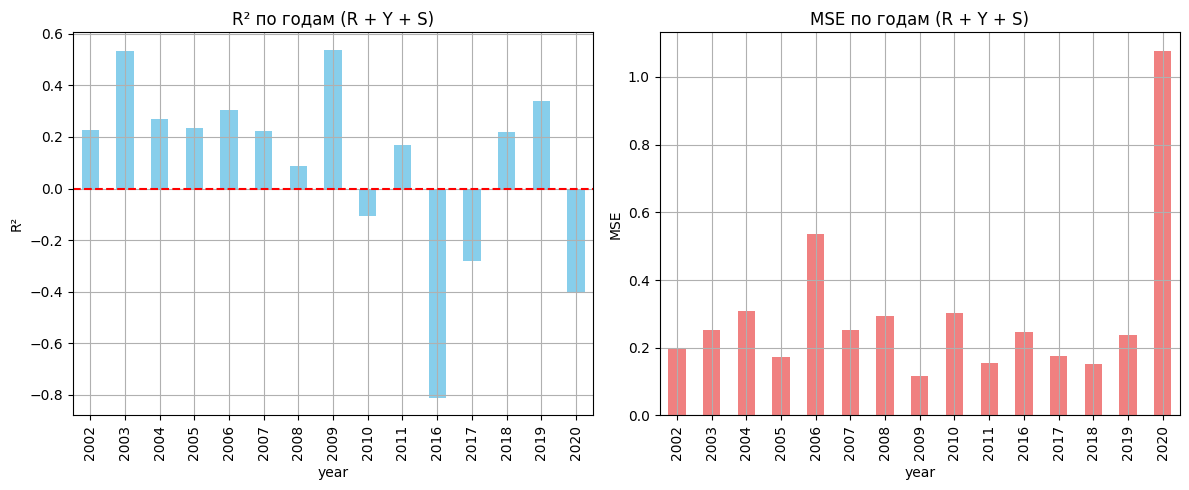

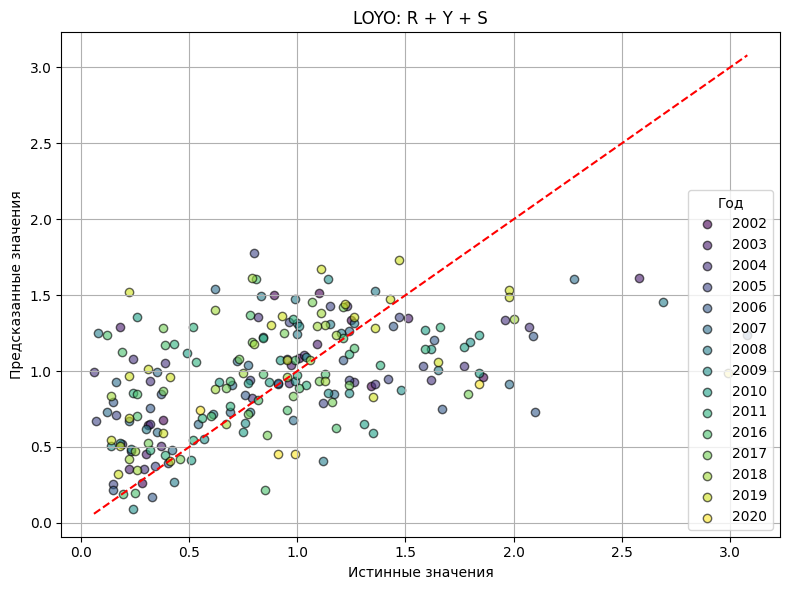

In [ ]:
#(глубина 0 м) — Hist - 230 строк обучения - усреднениe данных по неделям - не нормированные данные

import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Пути к данным ---
y_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y1_(глубина_=_0).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

# --- Загрузка R и Y ---
def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']].rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

df_y = pd.read_csv(y_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'].astype(str).str.replace(',', '.'), errors='coerce')

# --- Усреднение по неделям ---
def weekly_average(df, value_col, name):
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_col].mean().reset_index()
    df_weekly = df_weekly.rename(columns={value_col: name})
    return df_weekly

r1_weekly = weekly_average(r1, 'R1', 'R1')
r2_weekly = weekly_average(r2, 'R2', 'R2')
r3_weekly = weekly_average(r3, 'R3', 'R3')
y_weekly  = weekly_average(df_y, 'chlorophyll', 'chlorophyll')

# --- Inner merge R+Y → только совпадающие недели ---
df_merge = r1_weekly.merge(r2_weekly, on='week_start', how='inner') \
                    .merge(r3_weekly, on='week_start', how='inner') \
                    .merge(y_weekly, on='week_start', how='inner')
print("Количество недельных строк после объединения R и Y:", df_merge.shape[0])  # 230
week_index = df_merge['week_start']

# --- Загрузка S и усреднение по неделям ---
def load_s_weekly(path, name, week_index):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    value_cols = [c for c in df.columns if c not in ['date']]
    df[value_cols] = df[value_cols].replace(0.0, np.nan)  # нули → пропуски
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_cols].mean()  # NaN игнорируются
    df_weekly = df_weekly.loc[df_weekly.index.isin(week_index)]
    df_weekly.columns = [f'{name}_{c}' for c in df_weekly.columns]
    return df_weekly

s1_weekly = load_s_weekly(s1_path, 'S1', week_index)
s2_weekly = load_s_weekly(s2_path, 'S2', week_index)
s3_weekly = load_s_weekly(s3_path, 'S3', week_index)

# --- Создание двух наборов признаков ---
# Сначала индексируем df_merge по week_start
df_merge_indexed = df_merge.set_index('week_start')

# 1) R+Y
X_R = df_merge_indexed[['R1','R2','R3']].copy()

# 2) R+Y+S
X_RS = df_merge_indexed[['R1','R2','R3']].join([s1_weekly, s2_weekly, s3_weekly])

y = df_merge_indexed['chlorophyll']
groups = df_merge_indexed.index.year

print("Форма X_R:", X_R.shape)  # 230 x 3
print("Форма X_RS:", X_RS.shape)  # 230 x (3 + S1+S2+S3)

# --- LOYO CV функция ---
def train_and_plot(X, y, groups, title="Модель"):
    model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneGroupOut(), groups=groups)
    
    df_result = pd.DataFrame({'y_true': y, 'y_pred': y_pred, 'year': groups})
    
    # Метрики
    r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
    mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pred']))
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    print(f"\n{title}")
    print(f"Общие метрики: MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # Графики
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    r2_by_year.plot(kind='bar', color='skyblue')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'R² по годам ({title})')
    plt.ylabel('R²')
    plt.grid(True)

    plt.subplot(1,2,2)
    mse_by_year.plot(kind='bar', color='lightcoral')
    plt.title(f'MSE по годам ({title})')
    plt.ylabel('MSE')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Scatter plot с цветом по годам
    plt.figure(figsize=(8,6))
    years_sorted = sorted(df_result['year'].unique())
    colors = cm.viridis(np.linspace(0,1,len(years_sorted)))
    for yr, color in zip(years_sorted, colors):
        mask = df_result['year']==yr
        plt.scatter(df_result.loc[mask,'y_true'], df_result.loc[mask,'y_pred'], alpha=0.6, edgecolor='k', label=str(yr), color=color)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"LOYO: {title}")
    plt.legend(title="Год")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return y_pred

# --- Обучение и визуализация ---
y_pred_R = train_and_plot(X_R, y, groups, title="R + Y")
y_pred_RS = train_and_plot(X_RS, y, groups, title="R + Y + S")


Количество недельных строк после объединения R и Y: 230


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

Форма X_R: (230, 3)
Форма X_RS: (230, 6462)


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_


R + Y
Общие метрики: MSE=0.3011, RMSE=0.5487, R²=0.1866


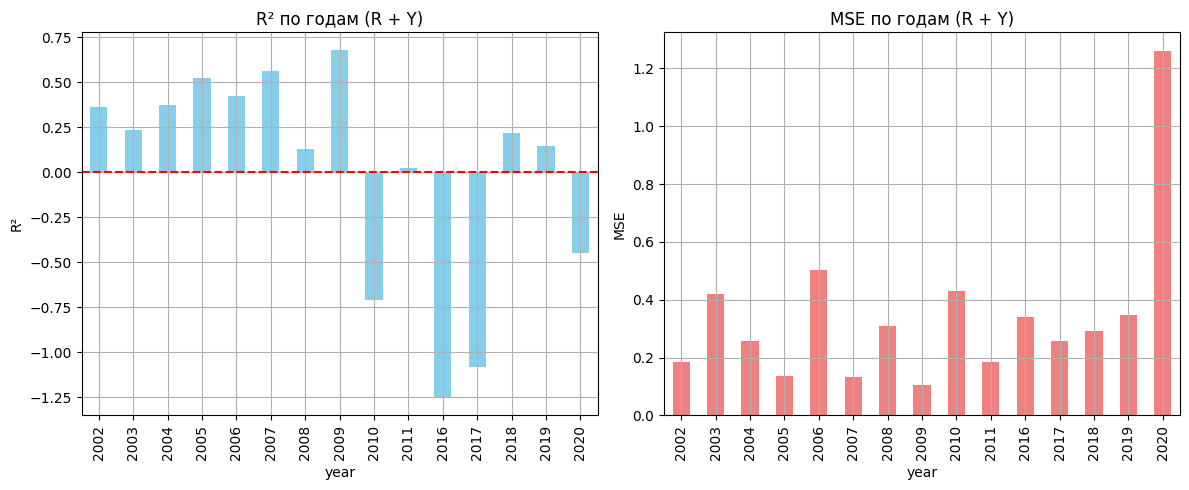

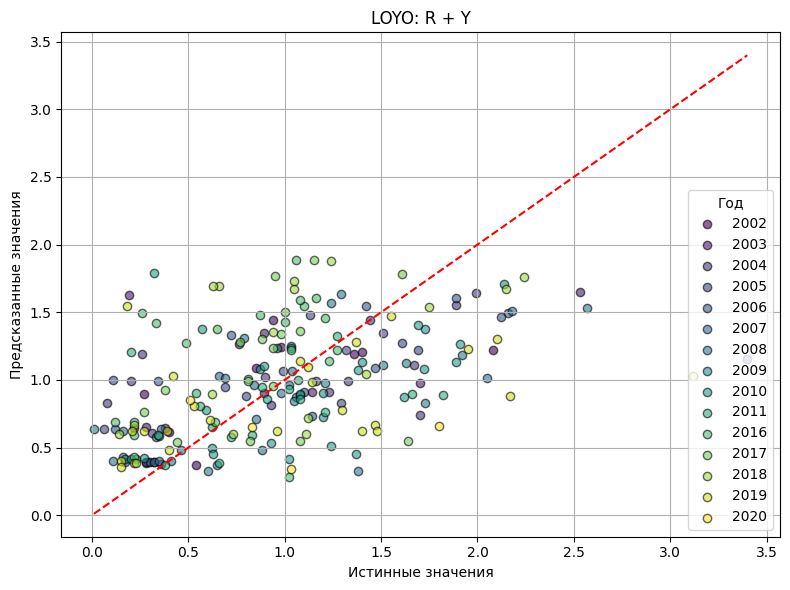

C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\3239347805.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_


R + Y + S
Общие метрики: MSE=0.2453, RMSE=0.4953, R²=0.3372


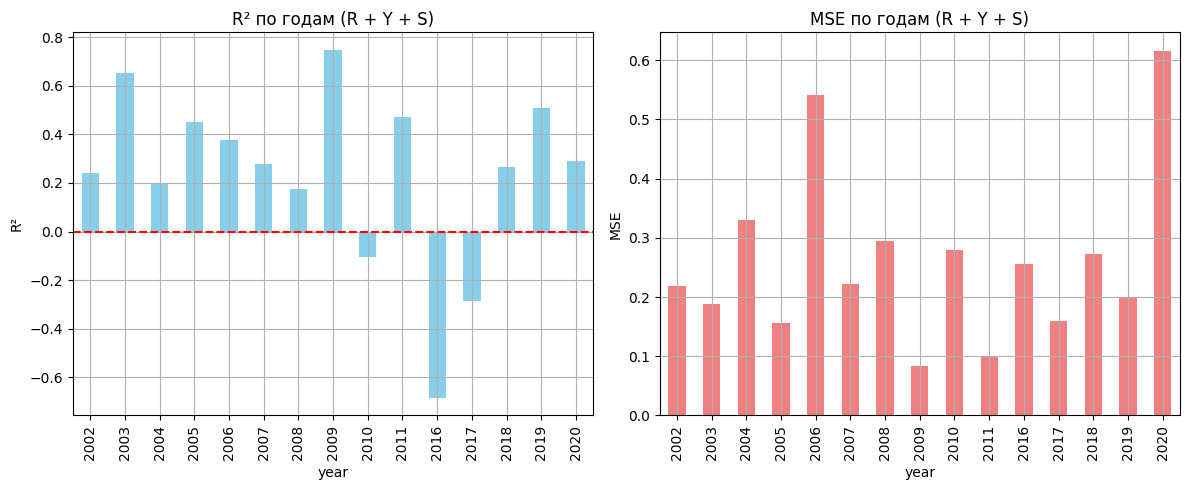

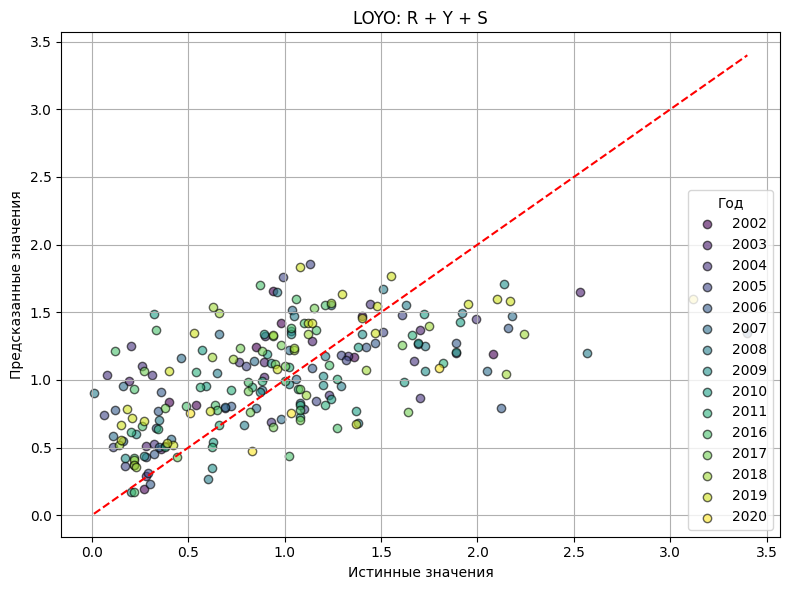

In [46]:
#(глубина 5 м) — Hist - 230 строк обучения - усреднениe данных по неделям - не нормированные данные

import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Пути к данным ---
y_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y2_(глубина_=_5).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

# --- Загрузка R и Y ---
def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']].rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

df_y = pd.read_csv(y_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'].astype(str).str.replace(',', '.'), errors='coerce')

# --- Усреднение по неделям ---
def weekly_average(df, value_col, name):
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_col].mean().reset_index()
    df_weekly = df_weekly.rename(columns={value_col: name})
    return df_weekly

r1_weekly = weekly_average(r1, 'R1', 'R1')
r2_weekly = weekly_average(r2, 'R2', 'R2')
r3_weekly = weekly_average(r3, 'R3', 'R3')
y_weekly  = weekly_average(df_y, 'chlorophyll', 'chlorophyll')

# --- Inner merge R+Y → только совпадающие недели ---
df_merge = r1_weekly.merge(r2_weekly, on='week_start', how='inner') \
                    .merge(r3_weekly, on='week_start', how='inner') \
                    .merge(y_weekly, on='week_start', how='inner')
print("Количество недельных строк после объединения R и Y:", df_merge.shape[0])  # 230
week_index = df_merge['week_start']

# --- Загрузка S и усреднение по неделям ---
def load_s_weekly(path, name, week_index):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    value_cols = [c for c in df.columns if c not in ['date']]
    df[value_cols] = df[value_cols].replace(0.0, np.nan)  # нули → пропуски
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_cols].mean()  # NaN игнорируются
    df_weekly = df_weekly.loc[df_weekly.index.isin(week_index)]
    df_weekly.columns = [f'{name}_{c}' for c in df_weekly.columns]
    return df_weekly

s1_weekly = load_s_weekly(s1_path, 'S1', week_index)
s2_weekly = load_s_weekly(s2_path, 'S2', week_index)
s3_weekly = load_s_weekly(s3_path, 'S3', week_index)

# --- Создание двух наборов признаков ---
# Сначала индексируем df_merge по week_start
df_merge_indexed = df_merge.set_index('week_start')

# 1) R+Y
X_R = df_merge_indexed[['R1','R2','R3']].copy()

# 2) R+Y+S
X_RS = df_merge_indexed[['R1','R2','R3']].join([s1_weekly, s2_weekly, s3_weekly])

y = df_merge_indexed['chlorophyll']
groups = df_merge_indexed.index.year

print("Форма X_R:", X_R.shape)  # 230 x 3
print("Форма X_RS:", X_RS.shape)  # 230 x (3 + S1+S2+S3)

# --- LOYO CV функция ---
def train_and_plot(X, y, groups, title="Модель"):
    model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneGroupOut(), groups=groups)
    
    df_result = pd.DataFrame({'y_true': y, 'y_pred': y_pred, 'year': groups})
    
    # Метрики
    r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
    mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pred']))
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    print(f"\n{title}")
    print(f"Общие метрики: MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # Графики
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    r2_by_year.plot(kind='bar', color='skyblue')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'R² по годам ({title})')
    plt.ylabel('R²')
    plt.grid(True)

    plt.subplot(1,2,2)
    mse_by_year.plot(kind='bar', color='lightcoral')
    plt.title(f'MSE по годам ({title})')
    plt.ylabel('MSE')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Scatter plot с цветом по годам
    plt.figure(figsize=(8,6))
    years_sorted = sorted(df_result['year'].unique())
    colors = cm.viridis(np.linspace(0,1,len(years_sorted)))
    for yr, color in zip(years_sorted, colors):
        mask = df_result['year']==yr
        plt.scatter(df_result.loc[mask,'y_true'], df_result.loc[mask,'y_pred'], alpha=0.6, edgecolor='k', label=str(yr), color=color)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"LOYO: {title}")
    plt.legend(title="Год")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return y_pred

# --- Обучение и визуализация ---
y_pred_R = train_and_plot(X_R, y, groups, title="R + Y")
y_pred_RS = train_and_plot(X_RS, y, groups, title="R + Y + S")


Количество недельных строк после объединения R и Y: 230


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

Форма X_R: (230, 3)
Форма X_RS: (230, 6462)


C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pr


R + Y
Общие метрики: MSE=0.3669, RMSE=0.6057, R²=0.1551


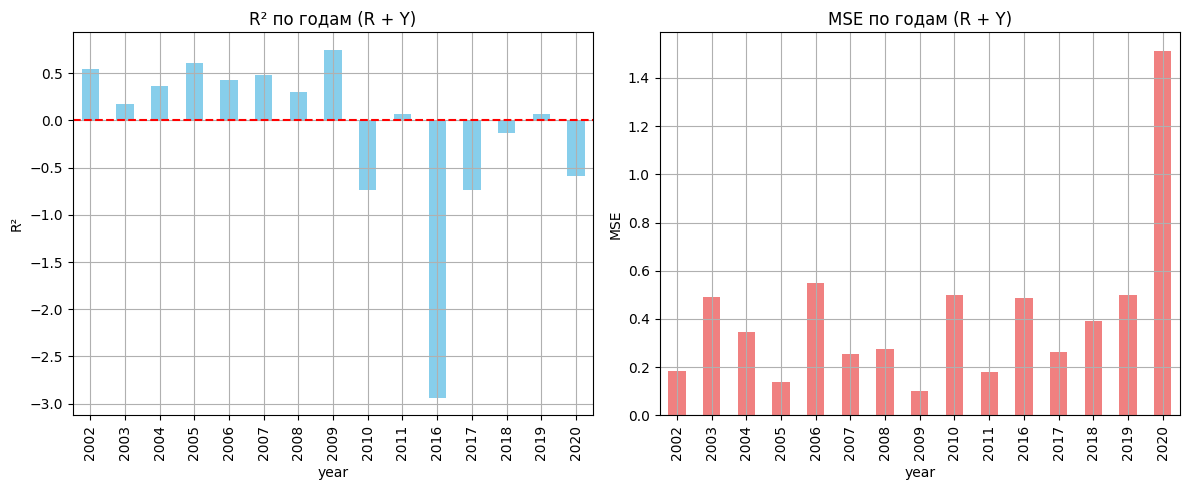

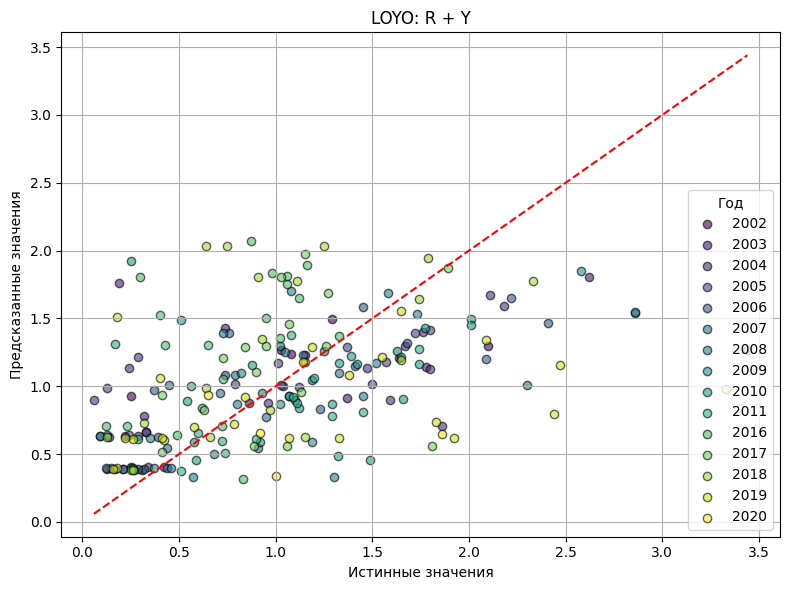

C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
C:\Users\fusb1\AppData\Local\Temp\ipykernel_8688\120949729.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pr


R + Y + S
Общие метрики: MSE=0.2885, RMSE=0.5371, R²=0.3356


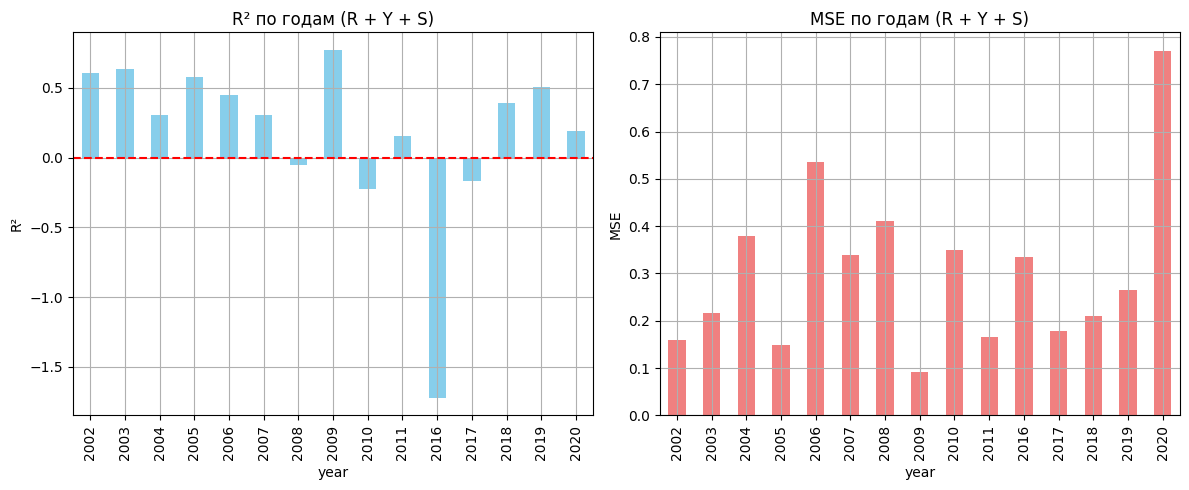

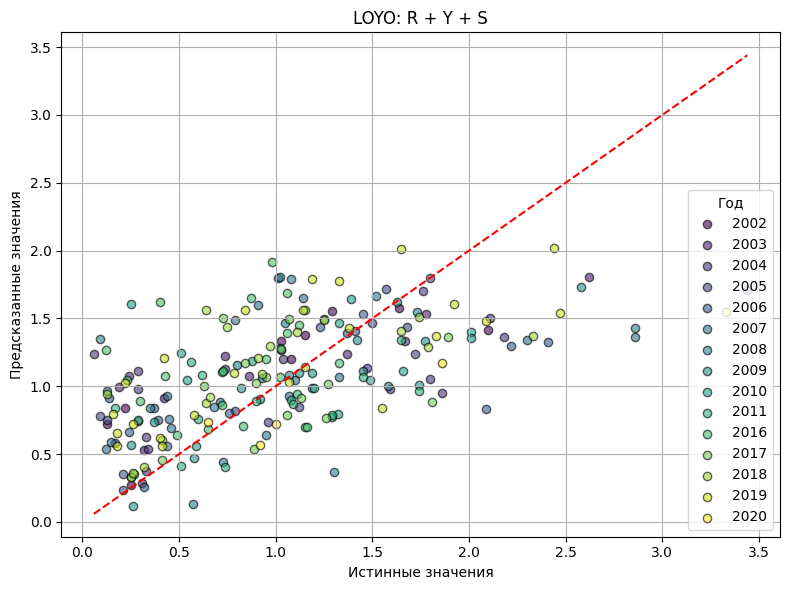

In [47]:
#(глубина 10 м) — Hist - 230 строк обучения - усреднениe данных по неделям - не нормированные данные

import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Пути к данным ---
y_path = "C:/Users/fusb1/Desktop/После Рыбки/Y_глубины/Y3_(глубина_=_10).csv"
r1_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_3_daily_Mean_Chla.csv"
r2_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_4.5_daily_Mean_Chla.csv"
r3_path = "C:/Users/fusb1/Desktop/После Рыбки/R_хлорофилл_спутник/Sputnik_radius_6_daily_Mean_Chla.csv"
s1_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_3000_матрица_из_ячеек_все_годы.csv"
s2_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_4500_матрица_из_ячеек_все_годы.csv"
s3_path = "C:/Users/fusb1/Desktop/Для диплома/Для_диплома_комп/ОЧИЩЕНО_6000_матрица_из_ячеек_все_годы.csv"

# --- Загрузка R и Y ---
def load_r(path, name):
    df = pd.read_csv(path)
    df = df[['date', 'chla_mean']].rename(columns={'chla_mean': name})
    df['date'] = pd.to_datetime(df['date'])
    return df

r1 = load_r(r1_path, 'R1')
r2 = load_r(r2_path, 'R2')
r3 = load_r(r3_path, 'R3')

df_y = pd.read_csv(y_path)
df_y.columns = ['date', 'chlorophyll']
df_y['date'] = pd.to_datetime(df_y['date'])
df_y['chlorophyll'] = pd.to_numeric(df_y['chlorophyll'].astype(str).str.replace(',', '.'), errors='coerce')

# --- Усреднение по неделям ---
def weekly_average(df, value_col, name):
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_col].mean().reset_index()
    df_weekly = df_weekly.rename(columns={value_col: name})
    return df_weekly

r1_weekly = weekly_average(r1, 'R1', 'R1')
r2_weekly = weekly_average(r2, 'R2', 'R2')
r3_weekly = weekly_average(r3, 'R3', 'R3')
y_weekly  = weekly_average(df_y, 'chlorophyll', 'chlorophyll')

# --- Inner merge R+Y → только совпадающие недели ---
df_merge = r1_weekly.merge(r2_weekly, on='week_start', how='inner') \
                    .merge(r3_weekly, on='week_start', how='inner') \
                    .merge(y_weekly, on='week_start', how='inner')
print("Количество недельных строк после объединения R и Y:", df_merge.shape[0])  # 230
week_index = df_merge['week_start']

# --- Загрузка S и усреднение по неделям ---
def load_s_weekly(path, name, week_index):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    value_cols = [c for c in df.columns if c not in ['date']]
    df[value_cols] = df[value_cols].replace(0.0, np.nan)  # нули → пропуски
    df['week_start'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    df_weekly = df.groupby('week_start')[value_cols].mean()  # NaN игнорируются
    df_weekly = df_weekly.loc[df_weekly.index.isin(week_index)]
    df_weekly.columns = [f'{name}_{c}' for c in df_weekly.columns]
    return df_weekly

s1_weekly = load_s_weekly(s1_path, 'S1', week_index)
s2_weekly = load_s_weekly(s2_path, 'S2', week_index)
s3_weekly = load_s_weekly(s3_path, 'S3', week_index)

# --- Создание двух наборов признаков ---
# Сначала индексируем df_merge по week_start
df_merge_indexed = df_merge.set_index('week_start')

# 1) R+Y
X_R = df_merge_indexed[['R1','R2','R3']].copy()

# 2) R+Y+S
X_RS = df_merge_indexed[['R1','R2','R3']].join([s1_weekly, s2_weekly, s3_weekly])

y = df_merge_indexed['chlorophyll']
groups = df_merge_indexed.index.year

print("Форма X_R:", X_R.shape)  # 230 x 3
print("Форма X_RS:", X_RS.shape)  # 230 x (3 + S1+S2+S3)

# --- LOYO CV функция ---
def train_and_plot(X, y, groups, title="Модель"):
    model = HistGradientBoostingRegressor(random_state=42, max_iter=100)
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneGroupOut(), groups=groups)
    
    df_result = pd.DataFrame({'y_true': y, 'y_pred': y_pred, 'year': groups})
    
    # Метрики
    r2_by_year = df_result.groupby('year').apply(lambda d: r2_score(d['y_true'], d['y_pred']))
    mse_by_year = df_result.groupby('year').apply(lambda d: mean_squared_error(d['y_true'], d['y_pred']))
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    
    print(f"\n{title}")
    print(f"Общие метрики: MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # Графики
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    r2_by_year.plot(kind='bar', color='skyblue')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'R² по годам ({title})')
    plt.ylabel('R²')
    plt.grid(True)

    plt.subplot(1,2,2)
    mse_by_year.plot(kind='bar', color='lightcoral')
    plt.title(f'MSE по годам ({title})')
    plt.ylabel('MSE')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Scatter plot с цветом по годам
    plt.figure(figsize=(8,6))
    years_sorted = sorted(df_result['year'].unique())
    colors = cm.viridis(np.linspace(0,1,len(years_sorted)))
    for yr, color in zip(years_sorted, colors):
        mask = df_result['year']==yr
        plt.scatter(df_result.loc[mask,'y_true'], df_result.loc[mask,'y_pred'], alpha=0.6, edgecolor='k', label=str(yr), color=color)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"LOYO: {title}")
    plt.legend(title="Год")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return y_pred

# --- Обучение и визуализация ---
y_pred_R = train_and_plot(X_R, y, groups, title="R + Y")
y_pred_RS = train_and_plot(X_RS, y, groups, title="R + Y + S")
